In [1]:
using ITensors, ITensorMPS
using ITransverse
using ITensorExpMPO
using ITensors: Algorithm
using Plots
using Plots.PlotMeasures
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)
using JLD2


using LsqFit

using Revise
includet("main.jl")

In [2]:
# Global Parameters
N = 40
target_times = collect(0.5 : 1.0 : 6.5) 
p = 0.5
lambda = 1.0
dt = 0.05
cutoff = 1e-14
maxdim = 256

# Setup finite chain and shared initial state
sites = siteinds("S=1/2", N)
psi0 = complex(MPS(sites, "X+"))

40-element MPS:
 ((dim=2|id=334|"S=1/2,Site,n=1"), (dim=1|id=166|"Link,l=1"))
 ((dim=1|id=166|"Link,l=1"), (dim=2|id=791|"S=1/2,Site,n=2"), (dim=1|id=702|"Link,l=2"))
 ((dim=1|id=702|"Link,l=2"), (dim=2|id=619|"S=1/2,Site,n=3"), (dim=1|id=278|"Link,l=3"))
 ((dim=1|id=278|"Link,l=3"), (dim=2|id=787|"S=1/2,Site,n=4"), (dim=1|id=914|"Link,l=4"))
 ((dim=1|id=914|"Link,l=4"), (dim=2|id=24|"S=1/2,Site,n=5"), (dim=1|id=662|"Link,l=5"))
 ((dim=1|id=662|"Link,l=5"), (dim=2|id=547|"S=1/2,Site,n=6"), (dim=1|id=685|"Link,l=6"))
 ((dim=1|id=685|"Link,l=6"), (dim=2|id=629|"S=1/2,Site,n=7"), (dim=1|id=612|"Link,l=7"))
 ((dim=1|id=612|"Link,l=7"), (dim=2|id=156|"S=1/2,Site,n=8"), (dim=1|id=227|"Link,l=8"))
 ((dim=1|id=227|"Link,l=8"), (dim=2|id=996|"S=1/2,Site,n=9"), (dim=1|id=337|"Link,l=9"))
 ((dim=1|id=337|"Link,l=9"), (dim=2|id=813|"S=1/2,Site,n=10"), (dim=1|id=888|"Link,l=10"))
 ⋮
 ((dim=1|id=515|"Link,l=31"), (dim=2|id=400|"S=1/2,Site,n=32"), (dim=1|id=840|"Link,l=32"))
 ((dim=1|id=840|"Link,l=3

In [9]:
# TVDP 
H_mpo = MPO(benchmark_opsum(N, lambda, p), sites)
psi_t_TDVP = deepcopy(psi0)
rate_TDVP = Float64[]
current_t = 0.0

@showprogress "TDVP Evolution..." for T in target_times
    steps = round(Int, (T - current_t) / dt)
    for _ in 1:steps
        global psi_t_TDVP = tdvp(H_mpo, -im * dt, psi_t_TDVP; cutoff=cutoff, maxdim=maxdim, nsite=2)
        normalize!(psi_t_TDVP) 
    end
    global current_t = T
    
    G_TDVP = inner(psi0, psi_t_TDVP)
    push!(rate_TDVP, -log(max(abs(G_TDVP), 1e-50)) / N)
    GC.gc()
end

jldsave("rate_TDVP.jld2"; rate_TDVP)

psi_t_TDVP = nothing
H_mpo = nothing
GC.gc()

TDVP Evolution... 100%|██████████████████████████████████| Time: 11:02:44


In [7]:
# VD2 
U_VD2 = expH_benchmark(sites, lambda, p; dt=dt, mpo_alg="VD2")
psi_t_VD2 = deepcopy(psi0)
rate_VD2 = Float64[]
current_t = 0.0

@showprogress "VD2 Evolution..." for T in target_times
    steps = round(Int, (T - current_t) / dt)
    for _ in 1:steps
        global psi_t_VD2 = apply(U_VD2, psi_t_VD2; cutoff=cutoff, maxdim=maxdim)
        normalize!(psi_t_VD2) 
    end
    global current_t = T
    
    G_VD2 = inner(psi0, psi_t_VD2)
    push!(rate_VD2, -log(max(abs(G_VD2), 1e-50)) / N)
    GC.gc()
end

jldsave("rate_VD2.jld2"; rate_VD2)

psi_t_VD2 = nothing
U_VD2 = nothing
GC.gc()

VD2 Evolution... 100%|███████████████████████████████████| Time: 0:34:12


In [15]:
# VD2 N = 200
N = 200

U_VD2 = expH_benchmark(sites, lambda, p; dt=dt, mpo_alg="VD2")
psi_t_VD2 = deepcopy(psi0)
rate_VD2 = Float64[]
current_t = 0.0

@showprogress "VD2 Evolution..." for T in target_times
    steps = round(Int, (T - current_t) / dt)
    for _ in 1:steps
        global psi_t_VD2 = apply(U_VD2, psi_t_VD2; cutoff=cutoff, maxdim=maxdim)
        normalize!(psi_t_VD2) 
    end
    global current_t = T
    
    G_VD2 = inner(psi0, psi_t_VD2)
    push!(rate_VD2, -log(max(abs(G_VD2), 1e-50)) / N)
    GC.gc()
end

jldsave("rate_VD2_200.jld2"; rate_VD2)

psi_t_VD2 = nothing
U_VD2 = nothing
GC.gc()

In [8]:
# WII
U_WII = expH_benchmark(sites, lambda, p; dt=dt, mpo_alg="WII")
psi_t_WII = deepcopy(psi0)
rate_WII = Float64[]
current_t = 0.0

@showprogress "WII Evolution..." for T in target_times
    steps = round(Int, (T - current_t) / dt)
    for _ in 1:steps
        global psi_t_WII = apply(U_WII, psi_t_WII; cutoff=cutoff, maxdim=maxdim)
        normalize!(psi_t_WII) 
    end
    global current_t = T
    
    G_WII = inner(psi0, psi_t_WII)
    push!(rate_WII, -log(max(abs(G_WII), 1e-50)) / N)
    GC.gc()
end

jldsave("rate_WII.jld2"; rate_WII)

psi_t_WII = nothing
U_WII = nothing
GC.gc()

WII Evolution... 100%|███████████████████████████████████| Time: 0:09:48


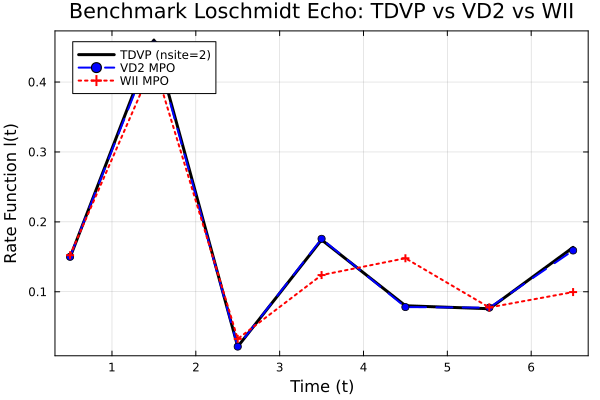

In [10]:
target_times = collect(0.5 : 1.0 : 6.5) 

# Load data safely from the JLD2 files
r_TDVP = load("rate_TDVP.jld2", "rate_TDVP")
r_VD2  = load("rate_VD2.jld2", "rate_VD2")
r_WII  = load("rate_WII.jld2", "rate_WII")

comparison_plot = plot(
    title="Benchmark Loschmidt Echo: TDVP vs VD2 vs WII",
    xlabel="Time (t)", 
    ylabel="Rate Function l(t)", 
    grid=true, framestyle=:box, legend=:topleft
)

plot!(comparison_plot, target_times, r_TDVP, label="TDVP (nsite=2)", lw=3, color=:black)
plot!(comparison_plot, target_times, r_VD2, label="VD2 MPO", lw=2, marker=:circle, ls=:dash, color=:blue)
plot!(comparison_plot, target_times, r_WII, label="WII MPO", lw=2, marker=:cross, ls=:dot, color=:red)

---

Let's try to benchmark the transverse contraction

In [ ]:
function compute_benchmark_entropies(
    target_T::Float64;
    p::Float64=0.0, lambda::Float64=1.0,
    dt::Float64=0.1, cutoff::Float64=1e-12, maxdim::Int=256, 
    alg::String="RTM", eps_converged::Float64=1e-6, nbeta::Int=4,
    MPO_alg::String="VD2"
)
    Ntime_steps = round(Int, target_T / dt)
    Nsteps = Ntime_steps + nbeta
    dbeta = -im * dt

    s = Index(2, "S=1/2")
    # Initial state |Psi0>
    init_state = complex(state(s, "X+"))  # |X+> state in Z basis

    RECIPES = Dict(
        "WI"  => BenchmarkWI(),
        "WII" => BenchmarkWII(),
        "VD2" => BenchmarkVD2()
    )
    
    # Build tMPO blocks
    mp_bench = BenchmarkParams(lambda=lambda, p=p, phys_site=s)
    tp = tMPOParams(
        mp=mp_bench; 
        dt=dt, 
        nbeta=nbeta, 
        scheme=RECIPES[MPO_alg],
        dbeta=dbeta, 
        bl=init_state
    )
    b = FwtMPOBlocks(tp)
    
    # Power Method Params
    pm_params = PMParams(;
        truncp = (; cutoff=cutoff, maxdim=maxdim, alg=alg), 
        opt_method = :nosym, 
        cutoffs = [cutoff], 
        maxdims = 2:2:maxdim, 
        itermax = 5000, 
        eps_converged = eps_converged, 
        normalization = "overlap",
        stuck_after = 200,
        compute_fidelity = true
    )

    # Dynamically determine spatial bond dimension
    spatial_bond_dim = dim(inds(b.Wc, "Site,time")[1])

    # The virtual links of the spatial MPO become the physical sites of the temporal MPS
    time_sites  = addtags(siteinds(spatial_bond_dim, Nsteps; conserve_qns=false), "time")

    # Build the transverse Transfer Matrix
    mpo         = fw_tMPO(b, time_sites, tr=init_state)
    # Temporal boundary (random so that it overlaps with the dominant eigenvector)
    start_mps   = fw_tMPS(b, time_sites; tr=init_state, LR=:right)

    # Run Power Method
    psi_L, psi_R, pm_info = ITransverse.powermethod_lr(start_mps, mpo, mpo, pm_params)

    # Normalize just in case
    norm = overlap_noconj(psi_L, psi_R)
    psi_L ./= sqrt(norm)
    psi_R ./= sqrt(norm)

    # Calculate entropy profiles (real and imaginary)
    p_r2_real = real.(ITransverse.gen_renyi2(psi_L, psi_R))
    p_r2_imag = imag.(ITransverse.gen_renyi2(psi_L, psi_R))

    bonds = 1:length(p_r2_real)

    return bonds, p_r2_real, p_r2_imag, psi_L, psi_R, mpo
end

compute_benchmark_entropies (generic function with 1 method)

In [ ]:
alg = "RTM"
eps_converged = 1e-6
nbeta = 0
MPO_alg = "VD2"

rate_trans_VD2 = Float64[]

@showprogress "Transverse Contraction ($MPO_alg)..." for T in target_times
    bonds, r2_re, r2_im, psi_L, psi_R, mpo = compute_benchmark_entropies(
        T; 
        lambda=lambda, p=p, dt=dt, cutoff=cutoff, maxdim=maxdim, 
        alg=alg, eps_converged=eps_converged, nbeta=nbeta, MPO_alg=MPO_alg
    )

    overlap_0 = overlap_noconj(psi_L, psi_R)
    
    if isnan(abs(overlap_0)) || abs(overlap_0) < 1e-25
        push!(rate_trans_VD2, NaN)
    else
        Lambda_0 = ITransverse.expval_LR(psi_L, mpo, psi_R) / overlap_0
        push!(rate_trans_VD2, -log(abs(Lambda_0)))
    end
    
    psi_L = nothing
    psi_R = nothing
    mpo = nothing
    GC.gc()
end

jldsave("rate_trans_VD2.jld2"; rate_trans_VD2)

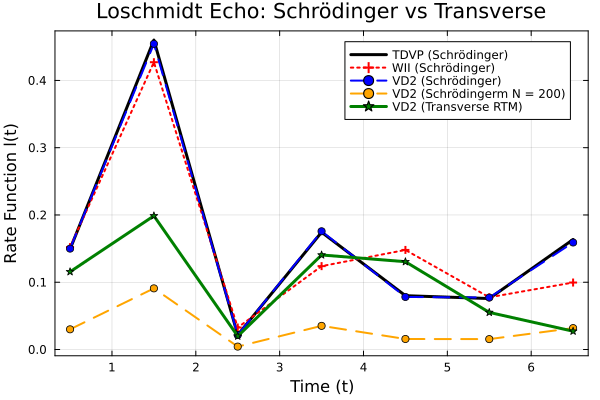

In [24]:
r_TDVP       = load("rate_TDVP.jld2", "rate_TDVP")
r_VD2_schrod = load("rate_VD2.jld2", "rate_VD2")
r_VD2_schrod_200 = load("rate_VD2_200.jld2", "rate_VD2")
r_WII_schrod = load("rate_WII.jld2", "rate_WII")
r_VD2_trans  = load("rate_trans_VD2.jld2", "rate_trans_VD2")

comparison_plot = plot(
    title="Loschmidt Echo: Schrödinger vs Transverse",
    xlabel="Time (t)", 
    ylabel="Rate Function l(t)", 
    grid=true, framestyle=:box, legend=:topright
)

plot!(comparison_plot, target_times, r_TDVP, label="TDVP (Schrödinger)", lw=3, color=:black)
plot!(comparison_plot, target_times, r_WII_schrod, label="WII (Schrödinger)", lw=2, marker=:cross, ls=:dot, color=:red)
plot!(comparison_plot, target_times, r_VD2_schrod, label="VD2 (Schrödinger)", lw=2, marker=:circle, ls=:dash, color=:blue)
plot!(comparison_plot, target_times, r_VD2_schrod_200, label="VD2 (Schrödingerm N = 200)", lw=2, marker=:circle, ls=:dash, color=:orange)

plot!(comparison_plot, target_times, r_VD2_trans, label="VD2 (Transverse RTM)", lw=3, marker=:star, color=:green)
 
display(comparison_plot)

---

In [27]:
""" Build a warm-start initial vector for the power method (TASK 2).

`warm` is a converged tMPS from a previous (shorter or equal) target time; `scaffold`
is a fresh `fw_tMPS` for the CURRENT length, used both for its correct site/link indices
and to supply the new tail tensors.

- Sites 1..length(warm) are taken from `warm`, with their physical (site) index reindexed
  onto the current `scaffold` site indices (the converged content is reused).
- If `warm` is shorter, the remaining tail is taken from `scaffold`. The converged prefix
  and the fresh tail are joined by a dimension-1 bridge link (the seed only needs to be a
  reasonable starting vector; the power method refines it).

Returns a normalized MPS whose indices are compatible with the current tMPO. """
function build_warm_start(warm::MPS, scaffold::MPS)
    L_old = length(warm)
    L_new = length(scaffold)
    @assert L_old <= L_new "warm start ($(L_old) sites) longer than current Nsteps ($(L_new))"

    old_s = siteinds(warm)
    new_s = siteinds(scaffold)

    tensors = Vector{ITensor}(undef, L_new)
    for i in 1:L_old
        tensors[i] = replaceind(warm[i], old_s[i], new_s[i])
    end

    if L_old < L_new
        # Join converged prefix (from warm) to fresh tail (from scaffold) via a dim-1 link.
        j  = Index(1, "Link,warm_bridge")
        fl = linkind(scaffold, L_old)              # scaffold link between sites L_old and L_old+1
        tensors[L_old]   = tensors[L_old] * onehot(j => 1)
        tensors[L_old+1] = (scaffold[L_old+1] * onehot(fl => 1)) * onehot(j => 1)
        for i in (L_old+2):L_new
            tensors[i] = scaffold[i]
        end
    end

    psi = MPS(tensors)
    normalize!(psi)
    return psi
end

function compute_benchmark_entropies_v2(
    target_T::Float64;
    p::Float64=0.0, lambda::Float64=1.0,
    dt::Float64=0.1, cutoff::Float64=1e-12, maxdim::Int=256, 
    alg::String="RTM", eps_converged::Float64=1e-6, nbeta::Int=4,
    MPO_alg::String="VD2",
    warm_L::Union{MPS,Nothing}=nothing, warm_R::Union{MPS,Nothing}=nothing
)
    Ntime_steps = round(Int, target_T / dt)
    Nsteps = Ntime_steps + nbeta
    dbeta = -im * dt

    s = Index(2, "S=1/2")
    # Initial state |Psi0>
    init_state = complex(state(s, "X+"))  # |X+> state in Z basis

    RECIPES = Dict(
        "WI"  => BenchmarkWI(),
        "WII" => BenchmarkWII(),
        "VD2" => BenchmarkVD2()
    )
    
    # Build tMPO blocks
    mp_bench = BenchmarkParams(lambda=lambda, p=p, phys_site=s)
    tp = tMPOParams(
        mp=mp_bench; 
        dt=dt, 
        nbeta=nbeta, 
        scheme=RECIPES[MPO_alg],
        dbeta=dbeta, 
        bl=init_state
    )
    b = FwtMPOBlocks(tp)
    
    # Power Method Params
    pm_params = PMParams(;
        truncp = (; cutoff=cutoff, maxdim=maxdim, alg=alg), 
        opt_method = :nosym, 
        cutoffs = [cutoff], 
        maxdims = 2:2:maxdim, 
        itermax = 5000, 
        eps_converged = eps_converged, 
        normalization = "overlap",
        stuck_after = 200,
        compute_fidelity = true
    )

    # Dynamically determine spatial bond dimension
    spatial_bond_dim = dim(inds(b.Wc, "Site,time")[1])

    # The virtual links of the spatial MPO become the physical sites of the temporal MPS
    time_sites  = addtags(siteinds(spatial_bond_dim, Nsteps; conserve_qns=false), "time")

    # Build the transverse Transfer Matrix
    mpo       = fw_tMPO(b, time_sites, tr=init_state)
    # Fresh fw_tMPS for the current length: supplies the correct site/link indices
    scaffold  = fw_tMPS(b, time_sites; tr=init_state, LR=:right)

    # --- Initial vector for the power method (TASK 2: warm starts) ---
    # powermethod_lr takes a SINGLE seed (it uses in_mps for both the left and right
    # boundaries: tlrapply(in_mps, mpo_L, mpo_R, in_mps)). We therefore seed from the
    # converged right vector warm_R; warm_L is threaded for API symmetry but cannot be
    # injected separately without modifying the library.
    start_mps = if warm_L === nothing || warm_R === nothing
        # No warm start: the structured fw_tMPS vector is symmetry-special and gets TRAPPED
        # in a subdominant Z2 sector for this benchmark (verified: it converges to
        # |Lambda0|=1.069 at T=1.5, vs the true dominant 1.202 found by generic seeds, which
        # agree to 3e-6 across random seeds). We therefore overwrite it with random tensors
        # so the power method reliably reaches the dominant eigenvalue.
        for i in eachindex(scaffold)
            scaffold[i] = randomITensor(ComplexF64, inds(scaffold[i]))
        end
        scaffold
    else
        # Warm start: reuse the converged right vector warm_R (sites reindexed; extended with
        # a fresh tail if the previous run was shorter). Generic enough to avoid the trap.
        build_warm_start(warm_R, scaffold)
    end
    normalize!(start_mps)

    # Run Power Method
    psi_L, psi_R, pm_info = ITransverse.powermethod_lr(start_mps, mpo, mpo, pm_params)

    # --- Convergence diagnostics (TASK 1) ---
    # powermethod_lr returns (ll, rr, info_iterations::Dict) with keys :ds, :fidelity, :chi.
    # There is NO explicit "reason" field, so we reconstruct it from the iteration history
    # using the same break conditions as pm_itercheck! (eps_converged / stuck_after / itermax).
    pm_final_ds = isempty(pm_info[:ds]) ? NaN : pm_info[:ds][end]
    pm_niters   = length(pm_info[:ds])
    pm_maxchi   = maxlinkdim(psi_R)
    pm_reason   = pm_final_ds < eps_converged ? "converged" :
                  (pm_niters >= pm_params.itermax ? "maxiter" : "stuck")
    println("[PM diag] T=$(target_T)  reason=$(pm_reason)  final_ds=$(pm_final_ds)  niters=$(pm_niters)  maxchi(psi_R)=$(pm_maxchi)")
    # --- end diagnostics ---

    # Normalize just in case
    norm = overlap_noconj(psi_L, psi_R)
    psi_L ./= sqrt(norm)
    psi_R ./= sqrt(norm)

    # Calculate entropy profiles (real and imaginary)
    p_r2_real = real.(ITransverse.gen_renyi2(psi_L, psi_R))
    p_r2_imag = imag.(ITransverse.gen_renyi2(psi_L, psi_R))

    # --- Keep only physical-time entries (TASK 4) ---
    # gen_renyi2 returns ONE value per INTERNAL BOND of the tMPS, so
    # length(p_r2_real) == Nsteps - 1 (per bond, not per site).
    # The tMPS is built with init_beta_only=false (the default of fw_tMPO/fw_tMPS), which
    # places imaginary-time cooling on the FIRST nbeta/2 and LAST nbeta/2 sites (split
    # front+back), NOT the first nbeta. We therefore trim nbeta/2 bonds from EACH end to
    # keep only physical real-time bonds. When nbeta=0 this is a no-op.
    nb_half   = div(nbeta, 2)
    keep      = (nb_half + 1) : (length(p_r2_real) - nb_half)
    p_r2_real = p_r2_real[keep]
    p_r2_imag = p_r2_imag[keep]

    # Actual physical times (Float64) for the kept bonds. Sized from the kept length so it
    # always matches the entropy vectors (length = Ntime_steps - 1 interior real-time bonds).
    times = collect((1:length(p_r2_real)) .* dt)

    # `times` replaces the old `bonds = 1:length(...)`; pm_info is the 4th return value (TASK 1)
    return times, p_r2_real, p_r2_imag, pm_info, psi_L, psi_R, mpo
end

compute_benchmark_entropies_v2 (generic function with 2 methods)

In [28]:
alg_b0 = "RTM"
eps_converged_b0 = 1e-6
nbeta_b0 = 0
MPO_alg_b0 = "VD2"

rate_trans_VD2_nbeta0 = Float64[]

# Warm-start state threaded across target times (independent of the nbeta=4 loop above).
prev_psi_L_b0 = nothing
prev_psi_R_b0 = nothing

@showprogress "Transverse Contraction (nbeta=0, $MPO_alg_b0)..." for T in target_times
    times, r2_re, r2_im, pm_info_T, psi_L, psi_R, mpo = compute_benchmark_entropies_v2(
        T; 
        lambda=lambda, p=p, dt=dt, cutoff=cutoff, maxdim=maxdim, 
        alg=alg_b0, eps_converged=eps_converged_b0, nbeta=nbeta_b0, MPO_alg=MPO_alg_b0,
        warm_L=prev_psi_L_b0, warm_R=prev_psi_R_b0
    )

    # Convergence verdict (same criterion the function uses internally)
    final_ds  = pm_info_T[:ds][end]
    converged = final_ds < eps_converged_b0
    println("  -> pm_info_T at T=$T: niters=$(length(pm_info_T[:ds])), final_ds=$final_ds, maxchi=$(maximum(pm_info_T[:chi])), converged=$converged")

    overlap_0 = overlap_noconj(psi_L, psi_R)
    
    if isnan(abs(overlap_0)) || abs(overlap_0) < 1e-25
        push!(rate_trans_VD2_nbeta0, NaN)
    else
        Lambda_0 = ITransverse.expval_LR(psi_L, mpo, psi_R) / overlap_0
        push!(rate_trans_VD2_nbeta0, -log(abs(Lambda_0)))
    end

    # Propagate the warm start ONLY if this run converged; otherwise keep the previous one.
    if converged
        prev_psi_L_b0 = psi_L
        prev_psi_R_b0 = psi_R
    end
    
    mpo = nothing
    GC.gc()
end

jldsave("rate_trans_VD2.jld2"; rate_trans_VD2_nbeta0)

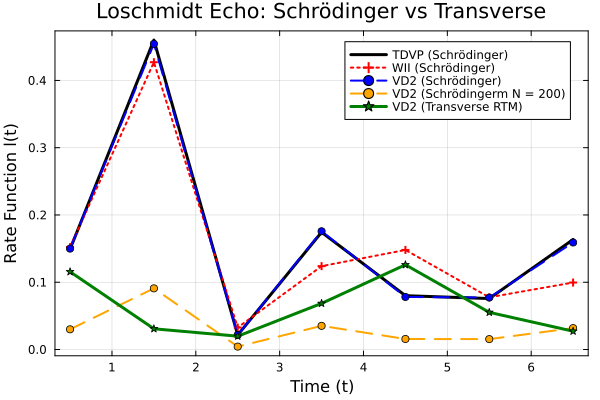

In [30]:
r_TDVP       = load("rate_TDVP.jld2", "rate_TDVP")
r_VD2_schrod = load("rate_VD2.jld2", "rate_VD2")
r_VD2_schrod_200 = load("rate_VD2_200.jld2", "rate_VD2")
r_WII_schrod = load("rate_WII.jld2", "rate_WII")
r_VD2_trans  = load("rate_trans_VD2.jld2", "rate_trans_VD2_nbeta0")

comparison_plot = plot(
    title="Loschmidt Echo: Schrödinger vs Transverse",
    xlabel="Time (t)", 
    ylabel="Rate Function l(t)", 
    grid=true, framestyle=:box, legend=:topright
)

plot!(comparison_plot, target_times, r_TDVP, label="TDVP (Schrödinger)", lw=3, color=:black)
plot!(comparison_plot, target_times, r_WII_schrod, label="WII (Schrödinger)", lw=2, marker=:cross, ls=:dot, color=:red)
plot!(comparison_plot, target_times, r_VD2_schrod, label="VD2 (Schrödinger)", lw=2, marker=:circle, ls=:dash, color=:blue)
plot!(comparison_plot, target_times, r_VD2_schrod_200, label="VD2 (Schrödingerm N = 200)", lw=2, marker=:circle, ls=:dash, color=:orange)

plot!(comparison_plot, target_times, r_VD2_trans, label="VD2 (Transverse RTM)", lw=3, marker=:star, color=:green)
 
display(comparison_plot)

---

In [37]:
# --- Deflation helpers (adapted from 7_gap.ipynb: gen_exc1_right / gen_exc1_left / compute_spectral_gap_LR) ---

function gen_exc1_right(in_mpo::MPO, psi_L_0::MPS, psi_R_0::MPS, lambda0::Number, in_mps_R::MPS; pm_cutoff=1e-10, maxdim::Int=256)
    opsi = applyn(in_mpo, in_mps_R; cutoff=pm_cutoff, maxdim=maxdim)
    n_opsi = norm(opsi)
    if n_opsi > 1e-25
        opsi ./= n_opsi
    end
    projpsi = overlap_noconj(psi_L_0, opsi) * psi_R_0
    return add(opsi, -projpsi; cutoff=pm_cutoff)
end

function gen_exc1_left(in_mpo_dag::MPO, psi_L_0::MPS, psi_R_0::MPS, lambda0::Number, in_mps_L::MPS; pm_cutoff=1e-10, maxdim::Int=256)
    opsi = applyn(in_mpo_dag, in_mps_L; cutoff=pm_cutoff, maxdim=maxdim)
    n_opsi = norm(opsi)
    if n_opsi > 1e-25
        opsi ./= n_opsi
    end
    projpsi = overlap_noconj(psi_R_0, opsi) * psi_L_0
    return add(opsi, -projpsi; cutoff=pm_cutoff)
end

# Subleading eigenvalue lambda_1 via deflation against the dominant pair (psi_L_0, psi_R_0).
# Tracks per-iteration |Delta lambda_1| (ds) and a convergence reason, unlike 7_gap.ipynb's
# compute_spectral_gap_LR which always runs a fixed itermax with no diagnostics.
function compute_spectral_gap_LR_diag(psi_L_0::MPS, psi_R_0::MPS, mpo::MPO;
                                       itermax::Int=200, cutoff::Float64=1e-10,
                                       maxdim::Int=256, eps_converged::Float64=1e-6)
    overlap_0 = overlap_noconj(psi_L_0, psi_R_0)
    if isnan(abs(overlap_0)) || abs(overlap_0) < 1e-25
        return NaN + NaN*im, Dict(:ds => Float64[], :niters => 0, :reason => "degenerate_overlap0")
    end
    lambda_0 = expval_LR(psi_L_0, mpo, psi_R_0) / overlap_0

    mpo_dag = swapprime(dag(mpo), 0, 1)

    # Random seed deflated against (psi_L_0, psi_R_0). For an unlucky draw the residual
    # after projection can have ~0 norm, and dividing by it produces NaNs that poison the
    # whole iteration (eigen() then throws on a NaN-filled matrix). Retry with fresh random
    # tensors until both residuals have a non-negligible norm.
    psi_R_1 = nothing
    psi_L_1 = nothing
    for attempt in 1:10
        cand = complex.(randomMPS(siteinds(psi_R_0), linkdims=4))
        cand ./= norm(cand)

        ov_R = overlap_noconj(psi_L_0, cand)
        cand_R = add(cand, (-ov_R) * psi_R_0; cutoff=cutoff)
        n_R = norm(cand_R)

        ov_L = overlap_noconj(psi_R_0, cand)
        cand_L = add(cand, (-ov_L) * psi_L_0; cutoff=cutoff)
        n_L = norm(cand_L)

        if n_R > 1e-8 && n_L > 1e-8
            psi_R_1 = cand_R / n_R
            psi_L_1 = cand_L / n_L
            break
        end
    end

    if psi_R_1 === nothing
        return NaN + NaN*im, Dict(:ds => Float64[], :niters => 0, :reason => "degenerate_init")
    end

    # The deflated power iteration below repeatedly truncates (cutoff/maxdim) and divides
    # by norms; on some T values this hits a numerically singular `add`/`eigen` step
    # (ArgumentError: NaNs or Infs) deep inside ITensorMPS. Rather than aborting the whole
    # T-loop, catch that case and report it like any other non-convergence (conv1_vals
    # already has a "numerical_error" bucket that the plot marks with a grey band).
    ds_hist = Float64[]
    lambda_1 = NaN + NaN*im
    reason = "maxiter"

    try
        for k in 1:itermax
            psi_R_1_unnorm = gen_exc1_right(mpo, psi_L_0, psi_R_0, lambda_0, psi_R_1; pm_cutoff=cutoff, maxdim=maxdim)
            n_R = norm(psi_R_1_unnorm)
            if n_R > 1e-20
                psi_R_1 = psi_R_1_unnorm / n_R
            end

            psi_L_1_unnorm = gen_exc1_left(mpo_dag, psi_L_0, psi_R_0, lambda_0, psi_L_1; pm_cutoff=cutoff, maxdim=maxdim)
            n_L = norm(psi_L_1_unnorm)
            if n_L > 1e-20
                psi_L_1 = psi_L_1_unnorm / n_L
            end

            overlap_1 = overlap_noconj(psi_L_1, psi_R_1)
            lambda_1_k = if abs(overlap_1) < 1e-14
                inner(psi_R_1, mpo, psi_R_1) / inner(psi_R_1, psi_R_1)
            else
                expval_LR(psi_L_1, mpo, psi_R_1) / overlap_1
            end

            if !isnan(lambda_1)
                push!(ds_hist, abs(lambda_1_k - lambda_1))
                if ds_hist[end] < eps_converged
                    lambda_1 = lambda_1_k
                    reason = "converged"
                    break
                end
            end
            lambda_1 = lambda_1_k
        end
    catch err
        if err isa ArgumentError
            reason = "numerical_error"
        else
            rethrow()
        end
    end

    info_defl = Dict(:ds => ds_hist, :niters => length(ds_hist), :reason => reason)
    return lambda_1, info_defl
end

# --- Main loop: T = 0.5 : 0.5 : 6.5, benchmark model, nbeta=0 ---
times_gap = collect(0.5 : 0.5 : 6.5)

abs_lambda0_vals = Float64[]
abs_lambda1_vals = Float64[]
arg_lambda0_vals = Float64[]
arg_lambda1_vals = Float64[]
gap_ratio_vals   = Float64[]
conv0_vals       = String[]
conv1_vals       = String[]
pm_info0_all     = Vector{Dict}(undef, length(times_gap))
pm_info1_all     = Vector{Dict}(undef, length(times_gap))

println("########## Spectral gap analysis (nbeta=0) ##########")
@showprogress "Spectral gap (nbeta=0)..." for (i, T) in enumerate(times_gap)
    times, _, _, pm_info_0, psi_L, psi_R, mpo = compute_benchmark_entropies_v2(
        T; lambda=lambda, p=p, dt=dt, cutoff=cutoff, maxdim=maxdim,
        alg="RTM", eps_converged=1e-6, nbeta=0, MPO_alg="VD2"
    )

    overlap_0 = overlap_noconj(psi_L, psi_R)
    lambda_0  = ITransverse.expval_LR(psi_L, mpo, psi_R) / overlap_0

    lambda_1, info_defl = compute_spectral_gap_LR_diag(psi_L, psi_R, mpo;
        itermax=200, cutoff=1e-10, maxdim=maxdim, eps_converged=1e-6)

    push!(abs_lambda0_vals, abs(lambda_0))
    push!(abs_lambda1_vals, abs(lambda_1))
    push!(arg_lambda0_vals, angle(lambda_0))
    push!(arg_lambda1_vals, angle(lambda_1))
    push!(gap_ratio_vals, abs(lambda_1) / abs(lambda_0))

    pm_info0_all[i] = pm_info_0
    pm_info1_all[i] = info_defl

    ds0   = pm_info_0[:ds][end]
    conv0 = ds0 < 1e-6 ? "converged" : (length(pm_info_0[:ds]) >= 5000 ? "maxiter" : "stuck")
    conv1 = info_defl[:reason]
    push!(conv0_vals, conv0)
    push!(conv1_vals, conv1)

    println("  T=$T  |λ0|=$(round(abs(lambda_0), digits=5))  |λ1|=$(round(abs(lambda_1), digits=5))  " *
            "gap_ratio=$(round(gap_ratio_vals[end], digits=5))  " *
            "conv0=$conv0 (ds=$(round(ds0, sigdigits=3)))  conv1=$conv1 (niters=$(info_defl[:niters]))")

    mpo = nothing
    GC.gc()
end

jldsave("spectral_gap_nbeta0.jld2"; times_gap, abs_lambda0_vals, abs_lambda1_vals,
        arg_lambda0_vals, arg_lambda1_vals, gap_ratio_vals, conv0_vals, conv1_vals)

println("\nDONE: Spectral gap analysis")

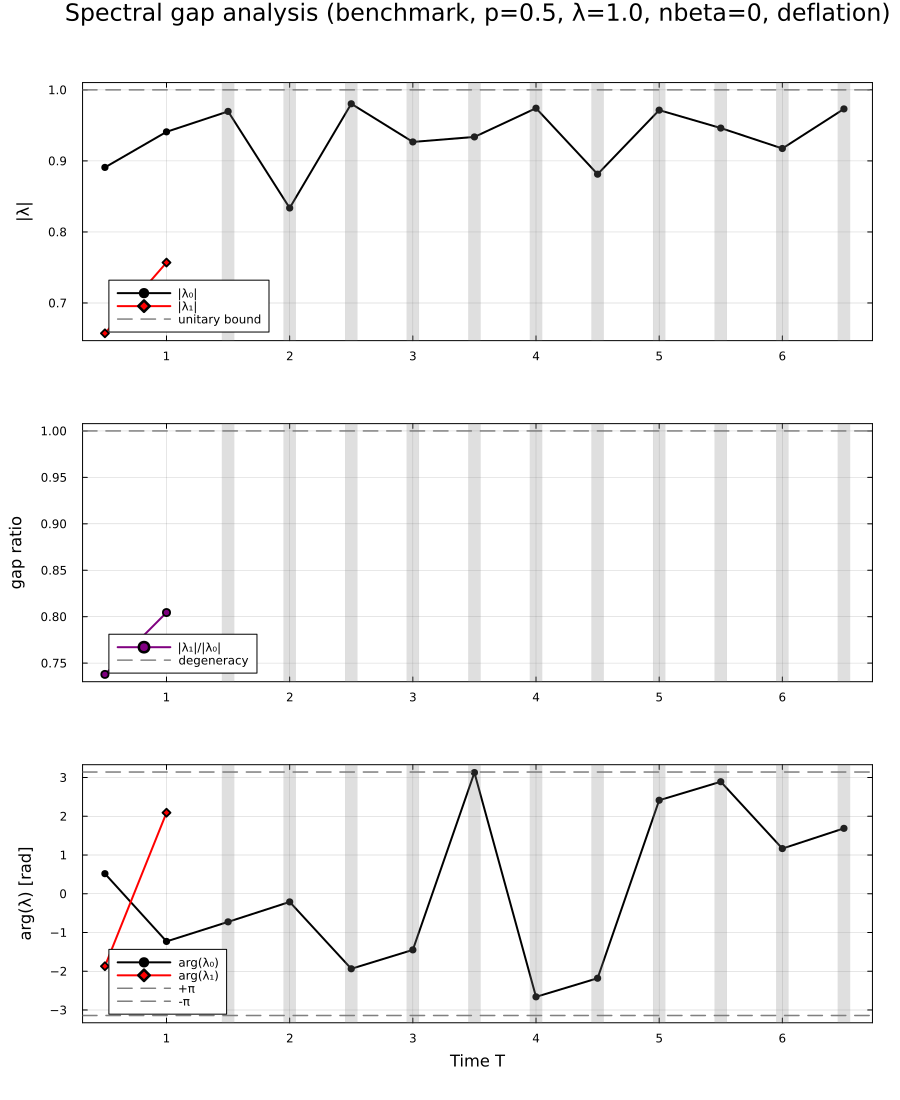

In [38]:
# --- 3-panel plot: |lambda_0|, |lambda_1|, gap_ratio, and phases vs physical time T ---

not_converged = [(conv0_vals[i] != "converged") || (conv1_vals[i] != "converged") for i in eachindex(times_gap)]

panel1 = plot(times_gap, abs_lambda0_vals, label="|λ₀|", lw=2, marker=:circle, color=:black,
               ylabel="|λ|", grid=true, framestyle=:box, legend=:best)
plot!(panel1, times_gap, abs_lambda1_vals, label="|λ₁|", lw=2, marker=:diamond, color=:red)
hline!(panel1, [1.0], label="unitary bound", lw=1.5, ls=:dash, color=:gray)

panel2 = plot(times_gap, gap_ratio_vals, label="|λ₁|/|λ₀|", lw=2, marker=:circle, color=:purple,
               ylabel="gap ratio", grid=true, framestyle=:box, legend=:best)
hline!(panel2, [1.0], label="degeneracy", lw=1.5, ls=:dash, color=:gray)

panel3 = plot(times_gap, arg_lambda0_vals, label="arg(λ₀)", lw=2, marker=:circle, color=:black,
               xlabel="Time T", ylabel="arg(λ) [rad]", grid=true, framestyle=:box, legend=:best)
plot!(panel3, times_gap, arg_lambda1_vals, label="arg(λ₁)", lw=2, marker=:diamond, color=:red)
hline!(panel3, [pi], label="+π", lw=1.5, ls=:dash, color=:gray)
hline!(panel3, [-pi], label="-π", lw=1.5, ls=:dash, color=:gray)

# Grey vertical bands at time points where lambda_0 (power method) or lambda_1 (deflation)
# did not converge.
for T in times_gap[not_converged]
    for panel in (panel1, panel2, panel3)
        vspan!(panel, [T - 0.05, T + 0.05], color=:gray, alpha=0.25, label="")
    end
end

gap_plot = plot(panel1, panel2, panel3, layout=(3, 1), size=(900, 1100), link=:x,
                margin=5Plots.mm,
                plot_title="Spectral gap analysis (benchmark, p=$p, λ=$lambda, nbeta=0, deflation)")

savefig(gap_plot, "spectral_gap_nbeta0.png")
display(gap_plot)

---

## Spectral gap — block (subspace) power method

The single-vector deflation above fails near the degeneracy at T≈1.5 (the gap closes — a DQPT). Here we
replace it with a **two-sided block power method** (oblique Petrov–Galerkin Rayleigh–Ritz) that extracts the
leading k=4 eigenvalues of the non-Hermitian transfer matrix **simultaneously** and stays well-behaved
through the degeneracy.

Conventions (all non-conjugating, **never `inner()`**):
- Right map `R ↦ applyn(mpo, R)`, left map `L ↦ applyn(swapprime(mpo,0,1), L)` — the **pure transpose**
  (no `dag`), the bilinear-form adjoint, so both maps share the same spectrum.
- Per iteration build the dense k×k pencil `S[i,j]=overlap_noconj(L_i,R_j)`,
  `M[i,j]=overlap_noconj(L_i, A·R_j)` and solve `M v = θ S v`. The Ritz values θ are the eigenvalue
  estimates; rotating the blocks to the Ritz vectors de-mixes the degenerate cluster (where deflation
  trapped/diverged). Bi-orthogonality is enforced **between** the L and R blocks (S), never within a block.

Outputs the eigenvalues **and** the matched, bi-orthonormal left/right eigenvectors for downstream use.
Results saved to `spectral_gap_block_nbeta0.jld2` / `spectral_gap_block_nbeta0.png` (the deflation cells and
their files are left intact for comparison).

In [3]:
using LinearAlgebra

# tMPO builder 
# returns only (mpo, scaffold) without doing any power-method run
function build_benchmark_tmpo(target_T::Float64;
        p::Float64=0.0, lambda::Float64=1.0, dt::Float64=0.05,
        nbeta::Int=0, MPO_alg::String="VD2")
    Ntime_steps = round(Int, target_T / dt)
    Nsteps = Ntime_steps + nbeta
    s = Index(2, "S=1/2")
    init_state = complex(state(s, "X+"))
    RECIPES = Dict("WI"=>BenchmarkWI(), "WII"=>BenchmarkWII(), "VD2"=>BenchmarkVD2())
    mp_bench = BenchmarkParams(lambda=lambda, p=p, phys_site=s)
    tp = tMPOParams(mp=mp_bench; dt=dt, nbeta=nbeta, scheme=RECIPES[MPO_alg],
                    dbeta=-im*dt, bl=init_state)
    b = FwtMPOBlocks(tp)
    spatial_bond_dim = dim(inds(b.Wc, "Site,time")[1])
    time_sites = addtags(siteinds(spatial_bond_dim, Nsteps; conserve_qns=false), "time")
    mpo      = fw_tMPO(b, time_sites, tr=init_state)
    scaffold = fw_tMPS(b, time_sites; tr=init_state, LR=:right)
    return mpo, scaffold
end

# Truncated linear combination of MPS:  sum_i coeffs[i] * vecs[i]
# Uses the exact "directsum" combine then SVD-truncates
function lincomb_mps(coeffs::AbstractVector, vecs::AbstractVector{MPS};
                     cutoff::Float64=1e-12, maxdim::Int=256)
    acc = coeffs[1] * vecs[1]
    for i in 2:length(vecs)
        acc = +(acc, coeffs[i] * vecs[i]; alg="directsum")
    end
    truncate!(acc; cutoff=cutoff, maxdim=maxdim)
    return acc
end

""" Block (subspace) power method for the leading `k` eigenvalues of the non-Hermitian
transfer operator `mpo`, with separate left/right bases and a fully non-conjugating
(overlap_noconj) oblique Rayleigh-Ritz. Robust through degeneracy.

Returns (theta, L, R, info):
  theta :: Vector{ComplexF64}  the k Ritz values, sorted by |.| descending
  L, R  :: Vector{MPS}         matched, bi-normalized left/right eigenvectors
                               (overlap_noconj(L[j],R[j]) ≈ 1, overlap_noconj(L[i],R[j])≈0 for i≠j)
  info  :: Dict                :niters, :reason, :condS, :dtheta (history), :theta

"""
function block_transfer_eigs(mpo::MPO, scaffold::MPS;
        k::Int=4, maxdim::Int=256, cutoff::Float64=1e-12,
        itermax::Int=300, eps_conv::Float64=1e-8, n_track::Int=2,
        cond_thresh::Float64=1e10)

    sit  = siteinds(scaffold)
    mpoT = swapprime(mpo, 0, 1)            # pure transpose (no dag): bilinear-form adjoint

    rand_mps() = normalize(complex.(randomMPS(sit, linkdims=2k)))
    R = MPS[rand_mps() for _ in 1:k]
    L = MPS[rand_mps() for _ in 1:k]

    theta      = fill(NaN + 0im, k)
    theta_prev = fill(NaN + 0im, k)
    dtheta_hist = Float64[]
    condS_last  = NaN
    reason = "maxiter"
    niters = 0

    for it in 1:itermax
        niters = it

        # (1) advance each block vector one application; keep BOTH the pre-apply R/L (for S)
        #     and the applied AR/ATL (for M and the new basis).
        AR  = MPS[applyn(mpo,  R[j]; cutoff=cutoff, maxdim=maxdim) for j in 1:k]
        ATL = MPS[applyn(mpoT, L[j]; cutoff=cutoff, maxdim=maxdim) for j in 1:k]

        # (2) dense k×k oblique pencil (non-conjugating)
        S = Matrix{ComplexF64}(undef, k, k)
        M = Matrix{ComplexF64}(undef, k, k)
        for i in 1:k, j in 1:k
            S[i, j] = overlap_noconj(L[i], R[j])      # <L_i | R_j>
            M[i, j] = overlap_noconj(L[i], AR[j])     # <L_i | A | R_j>
        end
        condS_last = cond(S)

        # (3) Ritz values via S^{-1} M // pinv: robust to rank-deficient S, instead of eigen(M,S)
        W  = pinv(S; rtol=1e-12) * M
        Fr = eigen(W)
        permr = sortperm(abs.(Fr.values); rev=true)
        theta = Fr.values[permr]
        VR    = Fr.vectors[:, permr]

        # left pencil vectors = right eigvecs of the transposed pencil, matched to θ by
        # NEAREST complex value (robust at the DQPT where |θ0|≈|θ1| but phases differ).
        Wl = pinv(permutedims(S); rtol=1e-12) * permutedims(M)
        Fl = eigen(Wl)
        VL = Matrix{ComplexF64}(undef, k, k)
        used = falses(k)
        for j in 1:k
            best, bestd = 0, Inf
            for m in 1:k
                used[m] && continue
                d = abs(Fl.values[m] - theta[j])
                if isfinite(d) && d < bestd; bestd, best = d, m; end
            end
            best == 0 && (best = findfirst(!, used))
            used[best] = true
            VL[:, j] = Fl.vectors[:, best]
        end

        # (4) new basis = rotate the APPLIED block by the Ritz coefficients (advance + de-mix)
        Rnew = MPS[lincomb_mps(VR[:, j], AR;  cutoff=cutoff, maxdim=maxdim) for j in 1:k]
        Lnew = MPS[lincomb_mps(VL[:, j], ATL; cutoff=cutoff, maxdim=maxdim) for j in 1:k]

        # (5) keep block vectors UNIT-NORM only; the (M,S) pencil carries the overlap scale.
        #     Refresh any vector that collapsed to ~0 (rank loss as the block converges).
        for j in 1:k
            nr = norm(Rnew[j]); Rnew[j] = (isfinite(nr) && nr > 1e-300) ? normalize(Rnew[j]) : rand_mps()
            nl = norm(Lnew[j]); Lnew[j] = (isfinite(nl) && nl > 1e-300) ? normalize(Lnew[j]) : rand_mps()
        end
        R, L = Rnew, Lnew

        # (6) convergence on the leading n_track Ritz values
        ntr = min(n_track, k)
        if it > 1 && all(isfinite, theta_prev[1:ntr])
            dtheta = maximum(abs.(theta[1:ntr] .- theta_prev[1:ntr]))
            push!(dtheta_hist, dtheta)
            if dtheta < eps_conv
                reason = "converged"
                break
            end
        end
        theta_prev = copy(theta)

        # (7) degeneracy / rank guard: if S collapses (vectors fell onto the dominant pair),
        #     refresh the weakest direction with a fresh random, non-conj-deflated vector.
        if condS_last > cond_thresh && k >= 2
            jb = k
            r = rand_mps(); l = rand_mps()
            for a in 1:(k-1)
                r = lincomb_mps([1.0, -overlap_noconj(L[a], r)], MPS[r, R[a]]; cutoff=cutoff, maxdim=maxdim)
                l = lincomb_mps([1.0, -overlap_noconj(R[a], l)], MPS[l, L[a]]; cutoff=cutoff, maxdim=maxdim)
            end
            R[jb] = normalize(r); L[jb] = normalize(l)
            reason = (reason == "converged") ? reason : "refreshed"
        end
    end

    # final bi-normalization for downstream use: overlap_noconj(L[j],R[j]) = 1 where defined
    for j in 1:k
        ov = overlap_noconj(L[j], R[j])
        if abs(ov) > 1e-10
            L[j] = (1 / sqrt(ov)) * L[j]
            R[j] = (1 / sqrt(ov)) * R[j]
        end
    end

    info = Dict(:niters => niters, :reason => reason, :condS => condS_last,
                :dtheta => dtheta_hist, :theta => theta)
    return theta, L, R, info
end

block_transfer_eigs

In [4]:
times_gap = collect(0.5 : 0.5 : 3.5)
k_block   = 4
gapfile   = "spectral_gap_block_nbeta0.jld2"

done = isfile(gapfile) ? load(gapfile, "done") : Dict{Float64, NamedTuple}()

for T in times_gap
    if haskey(done, T); println("  T=$T  (cached)"); continue; end
    local theta, info
    try
        mpo, scaffold = build_benchmark_tmpo(T; p=p, lambda=lambda, dt=dt, nbeta=0, MPO_alg="VD2")
        theta, Lblk, Rblk, info = block_transfer_eigs(mpo, scaffold;
            k=k_block, maxdim=maxdim, cutoff=1e-12, itermax=300, eps_conv=1e-8, n_track=2)
    catch err
        if err isa Union{ArgumentError, LinearAlgebra.SingularException, LinearAlgebra.LAPACKException}
            theta = fill(NaN + NaN*im, k_block)
            info  = Dict(:niters=>0, :reason=>"numerical_error", :condS=>NaN)
        else
            rethrow()
        end
    end
    done[T] = (abs=abs.(theta[1:4]), arg=angle.(theta[1:2]),
               gap=abs(theta[2])/abs(theta[1]), conv=info[:reason], condS=info[:condS])
    jldsave(gapfile; done)   # crash-safe checkpoint after each T
    r = done[T]
    println("  T=$T  |θ0|=$(round(r.abs[1],digits=5))  |θ1|=$(round(r.abs[2],digits=5))  " *
            "|θ2|=$(round(r.abs[3],digits=5))  |θ3|=$(round(r.abs[4],digits=5))  " *
            "gap=$(round(r.gap,digits=4))  $(r.conv) (niters=$(info[:niters]), condS=$(round(r.condS,sigdigits=3)))")
    GC.gc()
end

# assemble sorted plotting arrays from the (possibly resumed) checkpoint
Ts = sort(collect(keys(done)))
times_gap   = Ts
b_abs0 = [done[T].abs[1] for T in Ts]; b_abs1 = [done[T].abs[2] for T in Ts]
b_abs2 = [done[T].abs[3] for T in Ts]; b_abs3 = [done[T].abs[4] for T in Ts]
b_arg0 = [done[T].arg[1] for T in Ts]; b_arg1 = [done[T].arg[2] for T in Ts]
b_gap_ratio = [done[T].gap for T in Ts]
b_conv = [done[T].conv for T in Ts]
b_condS = [done[T].condS for T in Ts]

println("\nDONE: block-method spectral gap — $(length(Ts)) points up to T=$(maximum(Ts))")

  T=0.5  (cached)
  T=1.0  (cached)
  T=1.5  (cached)
  T=2.0  (cached)


┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=204|"S=1/2,Site") <-> (dim=2|id=204|"S=1/2,Site")'
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:92
┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=3|id=479|"Link,l=1") <-> (dim=3|id=732|"Link,l=2"), normdiff = 0.7561649998144878
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=301|"S=1/2,Site") <-> (dim=2|id=301

  T=2.5  |θ0|=0.98042  |θ1|=0.87728  |θ2|=0.75611  |θ3|=0.75352  gap=0.8948  converged (niters=37, condS=3.5)


┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=3|id=793|"Link,l=1") <-> (dim=3|id=584|"Link,l=2"), normdiff = 1.044713884229721
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=68|"S=1/2,Site") <-> (dim=2|id=68|"S=1/2,Site")'
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:92


  T=3.0  |θ0|=0.9267  |θ1|=0.82369  |θ2|=0.80505  |θ3|=0.78803  gap=0.8888  converged (niters=114, condS=4.58)


┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=3|id=666|"Link,l=1") <-> (dim=3|id=741|"Link,l=2"), normdiff = 0.7561649998144878
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=479|"S=1/2,Site") <-> (dim=2|id=479|"S=1/2,Site")'
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:92
┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=3|id=238|"Link,l=1") <-> (dim=3|id=

  T=3.5  |θ0|=0.93375  |θ1|=0.86888  |θ2|=0.84606  |θ3|=0.79345  gap=0.9305  converged (niters=103, condS=5.07)


┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=3|id=559|"Link,l=1") <-> (dim=3|id=808|"Link,l=2"), normdiff = 0.7561649998144878
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Info: Tensor symmetric (dim=2|id=12|"S=1/2,Site") <-> (dim=2|id=12|"S=1/2,Site")'
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:92
┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=3|id=812|"Link,l=1") <-> (dim=3|id=90


DONE: block-method spectral gap — 7 points up to T=3.5


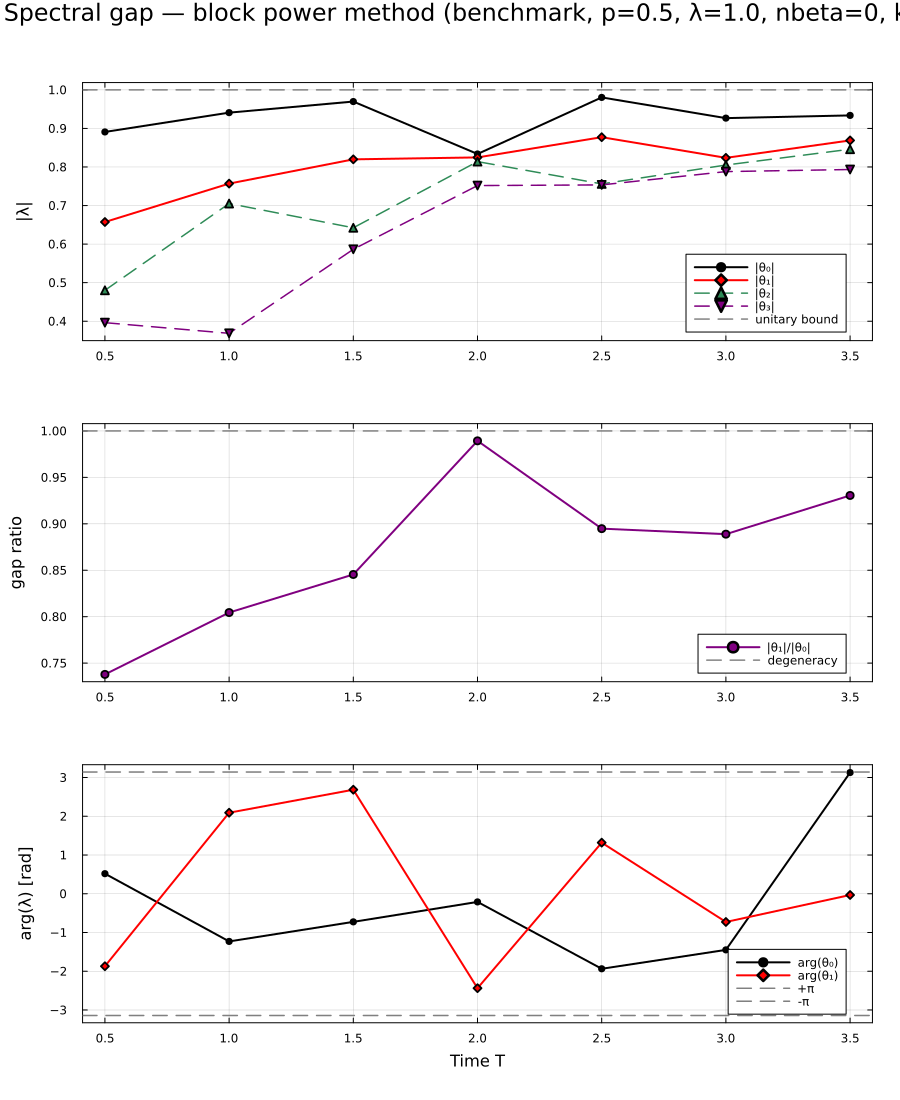

In [5]:
# --- Block-method 3-panel plot: |θ0..3|, gap ratio, phases vs physical time T ---
not_conv_b = [b_conv[i] != "converged" for i in eachindex(times_gap)]

bp1 = plot(times_gap, b_abs0, label="|θ₀|", lw=2, marker=:circle, color=:black,
           ylabel="|λ|", grid=true, framestyle=:box, legend=:best)
plot!(bp1, times_gap, b_abs1, label="|θ₁|", lw=2, marker=:diamond, color=:red)
plot!(bp1, times_gap, b_abs2, label="|θ₂|", lw=1.5, marker=:utriangle, ls=:dash, color=:seagreen)
plot!(bp1, times_gap, b_abs3, label="|θ₃|", lw=1.5, marker=:dtriangle, ls=:dash, color=:purple)
hline!(bp1, [1.0], label="unitary bound", lw=1.5, ls=:dash, color=:gray)

bp2 = plot(times_gap, b_gap_ratio, label="|θ₁|/|θ₀|", lw=2, marker=:circle, color=:purple,
           ylabel="gap ratio", grid=true, framestyle=:box, legend=:best)
hline!(bp2, [1.0], label="degeneracy", lw=1.5, ls=:dash, color=:gray)

bp3 = plot(times_gap, b_arg0, label="arg(θ₀)", lw=2, marker=:circle, color=:black,
           xlabel="Time T", ylabel="arg(λ) [rad]", grid=true, framestyle=:box, legend=:best)
plot!(bp3, times_gap, b_arg1, label="arg(θ₁)", lw=2, marker=:diamond, color=:red)
hline!(bp3, [pi],  label="+π", lw=1.5, ls=:dash, color=:gray)
hline!(bp3, [-pi], label="-π", lw=1.5, ls=:dash, color=:gray)

# grey bands where the block solver did not converge
for T in times_gap[not_conv_b]
    for pp in (bp1, bp2, bp3)
        vspan!(pp, [T - 0.05, T + 0.05], color=:gray, alpha=0.25, label="")
    end
end

gap_block_plot = plot(bp1, bp2, bp3, layout=(3, 1), size=(900, 1100), link=:x,
                      margin=5Plots.mm,
                      plot_title="Spectral gap — block power method (benchmark, p=$p, λ=$lambda, nbeta=0, k=$k_block)")
savefig(gap_block_plot, "spectral_gap_block_nbeta0.png")
display(gap_block_plot)